In [1]:
import os
os.chdir('/users/zzhan536/myData/Tutoring/mechanics_PINN/Basic-PiNN-Model-For-Three-Layered-Collision/pinn-workflow')
print(os.getcwd())

/oscar/data/gk/zzhan536/Tutoring/mechanics_PINN/Basic-PiNN-Model-For-Three-Layered-Collision/pinn-workflow


In [ ]:
from train import train 
train()

Using device: cuda
MultiLayerPINN(
  (layer): LayerNet(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=32, bias=True)
      (1): Tanh()
      (2): Linear(in_features=32, out_features=32, bias=True)
      (3): Tanh()
      (4): Linear(in_features=32, out_features=3, bias=True)
    )
  )
)
Loading FEM solution for comparison...
FEM data loaded: (31, 31, 11)
Starting Adam Training...
Epoch 0: Total Loss: 12.426712 | PDE: 11.557629 | BC_sides: 0.000000 | Free_top: 0.081434 | Free_bot: 0.078462 | Load: 0.709189 | LR: 1.00e-03 | FEM MAE: 0.124972 | Time: 0.2474s
Epoch 100: Total Loss: 0.169189 | PDE: 0.020527 | BC_sides: 0.000000 | Free_top: 0.023996 | Free_bot: 0.029593 | Load: 0.095073 | LR: 1.00e-03 | FEM MAE: 0.057777 | Time: 7.6922s
Epoch 200: Total Loss: 0.165166 | PDE: 0.021088 | BC_sides: 0.000000 | Free_top: 0.028308 | Free_bot: 0.034805 | Load: 0.080965 | LR: 1.00e-03 | FEM MAE: 0.057826 | Time: 7.6792s
Epoch 300: Total Loss: 0.163845 | PDE: 0.020403 | BC_side

# Visualize Training Data Distribution

Show the spatial distribution of collocation points used for training.

Training Data Statistics:
  Interior points: 10000
  BC Sides points: 1500
  Top Load patch: 750
  Top Free surface: 750
  Bottom surface: 1500
  Total: 14500

Saved training_data_distribution.png


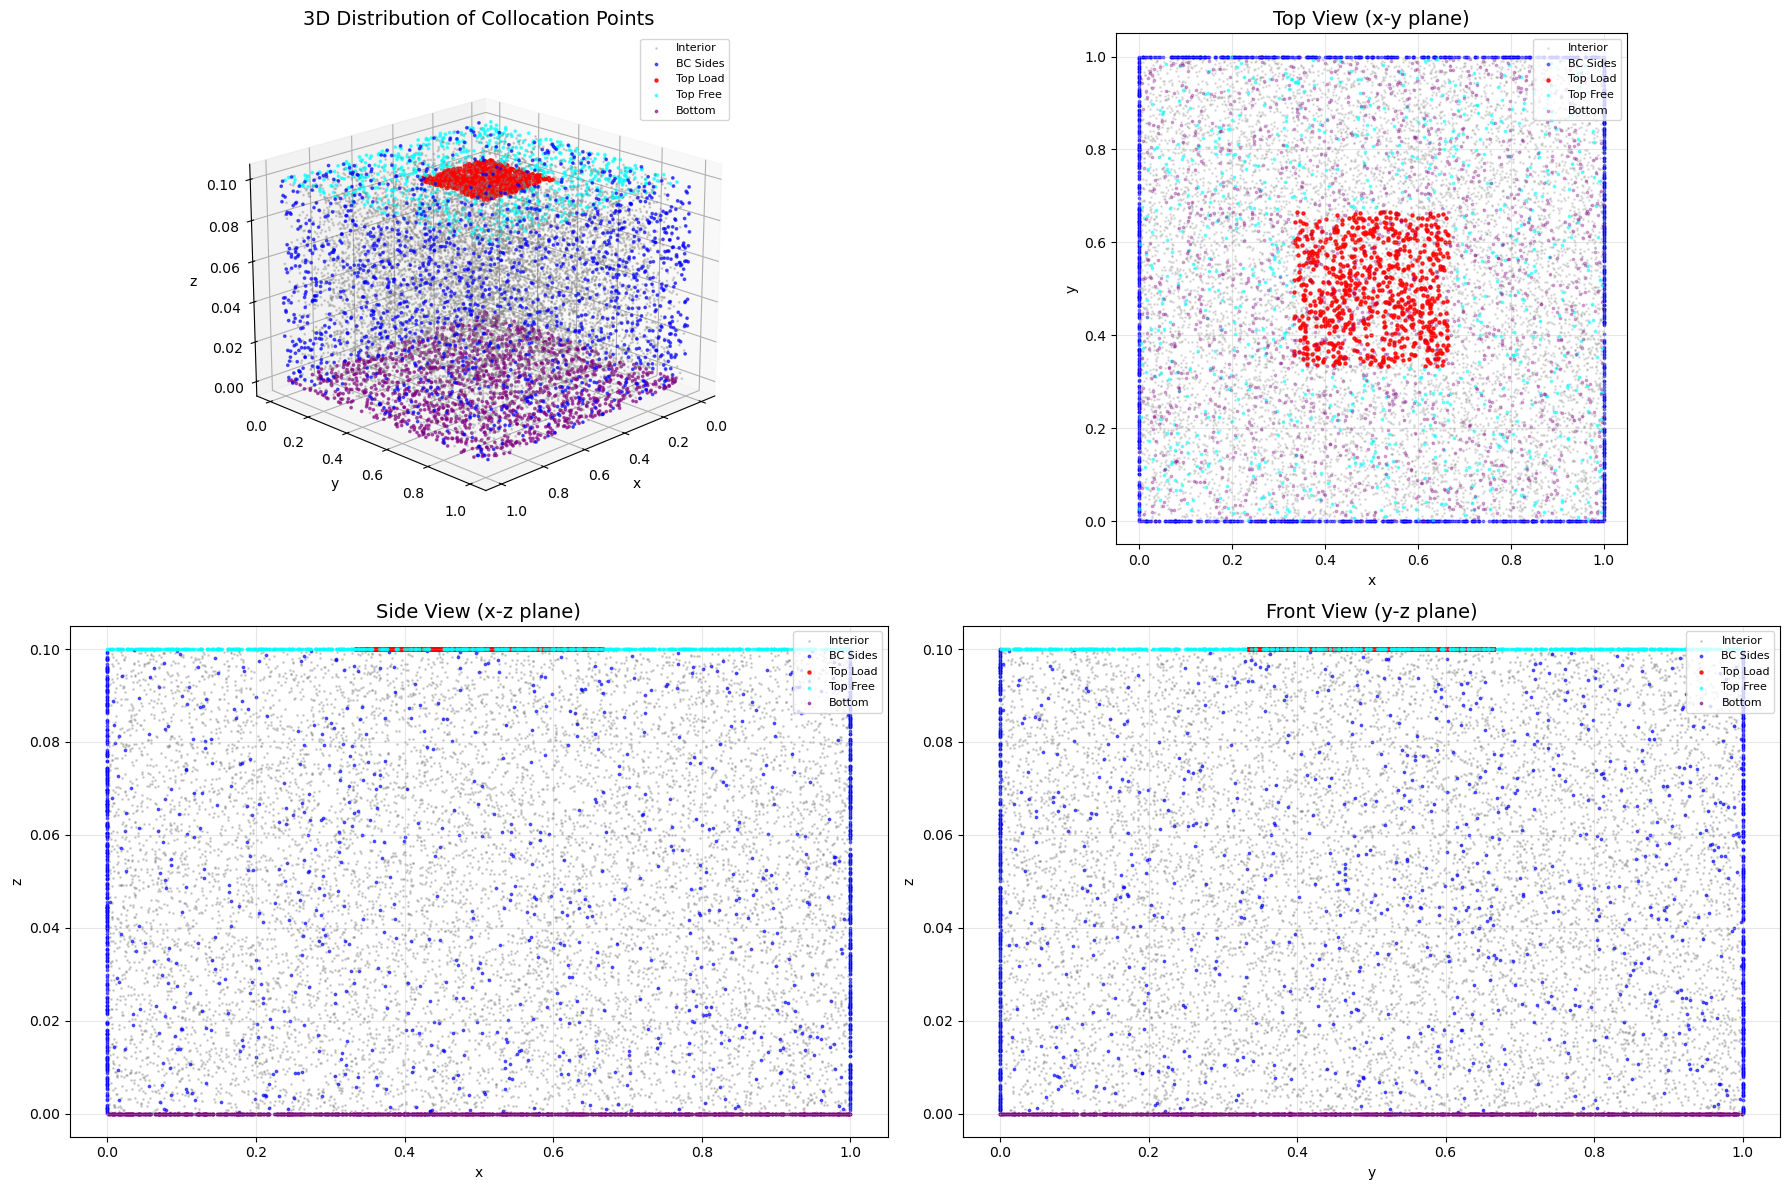

In [ ]:
# Generate a sample of training data
import data as data_module
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

training_data = data_module.get_data()

# Extract different types of collocation points
interior = training_data['interior'][0].numpy()
bc_sides = training_data['sides'][0].numpy()
top_load = training_data['top_load'].numpy()
top_free = training_data['top_free'].numpy()
bottom = training_data['bottom'].numpy()

print("Training Data Statistics:")
print(f"  Interior points: {interior.shape[0]}")
print(f"  BC Sides points: {bc_sides.shape[0]}")
print(f"  Top Load patch: {top_load.shape[0]}")
print(f"  Top Free surface: {top_free.shape[0]}")
print(f"  Bottom surface: {bottom.shape[0]}")
print(f"  Total: {interior.shape[0] + bc_sides.shape[0] + top_load.shape[0] + top_free.shape[0] + bottom.shape[0]}")

# Create 3D visualization
fig = plt.figure(figsize=(18, 12))

# 3D view
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter(interior[:, 0], interior[:, 1], interior[:, 2], c='gray', alpha=0.3, s=1, label='Interior')
ax1.scatter(bc_sides[:, 0], bc_sides[:, 1], bc_sides[:, 2], c='blue', alpha=0.6, s=3, label='BC Sides')
ax1.scatter(top_load[:, 0], top_load[:, 1], top_load[:, 2], c='red', alpha=0.8, s=5, label='Top Load')
ax1.scatter(top_free[:, 0], top_free[:, 1], top_free[:, 2], c='cyan', alpha=0.6, s=3, label='Top Free')
ax1.scatter(bottom[:, 0], bottom[:, 1], bottom[:, 2], c='purple', alpha=0.6, s=3, label='Bottom')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('3D Distribution of Collocation Points', fontsize=14)
ax1.legend(loc='upper right', fontsize=8)
ax1.view_init(elev=20, azim=45)

# Top view (x-y plane)
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(interior[:, 0], interior[:, 1], c='gray', alpha=0.2, s=1, label='Interior')
ax2.scatter(bc_sides[:, 0], bc_sides[:, 1], c='blue', alpha=0.5, s=3, label='BC Sides')
ax2.scatter(top_load[:, 0], top_load[:, 1], c='red', alpha=0.8, s=5, label='Top Load')
ax2.scatter(top_free[:, 0], top_free[:, 1], c='cyan', alpha=0.5, s=3, label='Top Free')
ax2.scatter(bottom[:, 0], bottom[:, 1], c='purple', alpha=0.3, s=3, label='Bottom')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Top View (x-y plane)', fontsize=14)
ax2.legend(loc='upper right', fontsize=8)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

# Side view (x-z plane)
ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(interior[:, 0], interior[:, 2], c='gray', alpha=0.3, s=1, label='Interior')
ax3.scatter(bc_sides[:, 0], bc_sides[:, 2], c='blue', alpha=0.6, s=3, label='BC Sides')
ax3.scatter(top_load[:, 0], top_load[:, 2], c='red', alpha=0.8, s=5, label='Top Load')
ax3.scatter(top_free[:, 0], top_free[:, 2], c='cyan', alpha=0.6, s=3, label='Top Free')
ax3.scatter(bottom[:, 0], bottom[:, 2], c='purple', alpha=0.6, s=3, label='Bottom')
ax3.set_xlabel('x')
ax3.set_ylabel('z')
ax3.set_title('Side View (x-z plane)', fontsize=14)
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.3)

# Front view (y-z plane)
ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(interior[:, 1], interior[:, 2], c='gray', alpha=0.3, s=1, label='Interior')
ax4.scatter(bc_sides[:, 1], bc_sides[:, 2], c='blue', alpha=0.6, s=3, label='BC Sides')
ax4.scatter(top_load[:, 1], top_load[:, 2], c='red', alpha=0.8, s=5, label='Top Load')
ax4.scatter(top_free[:, 1], top_free[:, 2], c='cyan', alpha=0.6, s=3, label='Top Free')
ax4.scatter(bottom[:, 1], bottom[:, 2], c='purple', alpha=0.6, s=3, label='Bottom')
ax4.set_xlabel('y')
ax4.set_ylabel('z')
ax4.set_title('Front View (y-z plane)', fontsize=14)
ax4.legend(loc='upper right', fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_data_distribution.png", dpi=150)
print("\nSaved training_data_distribution.png")
plt.show()

# Training Loss History

Visualize the loss evolution during training.

Training completed in 200100 steps
  Adam phase: 2000 epochs
  L-BFGS phase: 198100 steps
Final loss: 4.457052e-02
Initial loss: 1.195570e+01
Reduction: 268.24x

Saved training_history.png


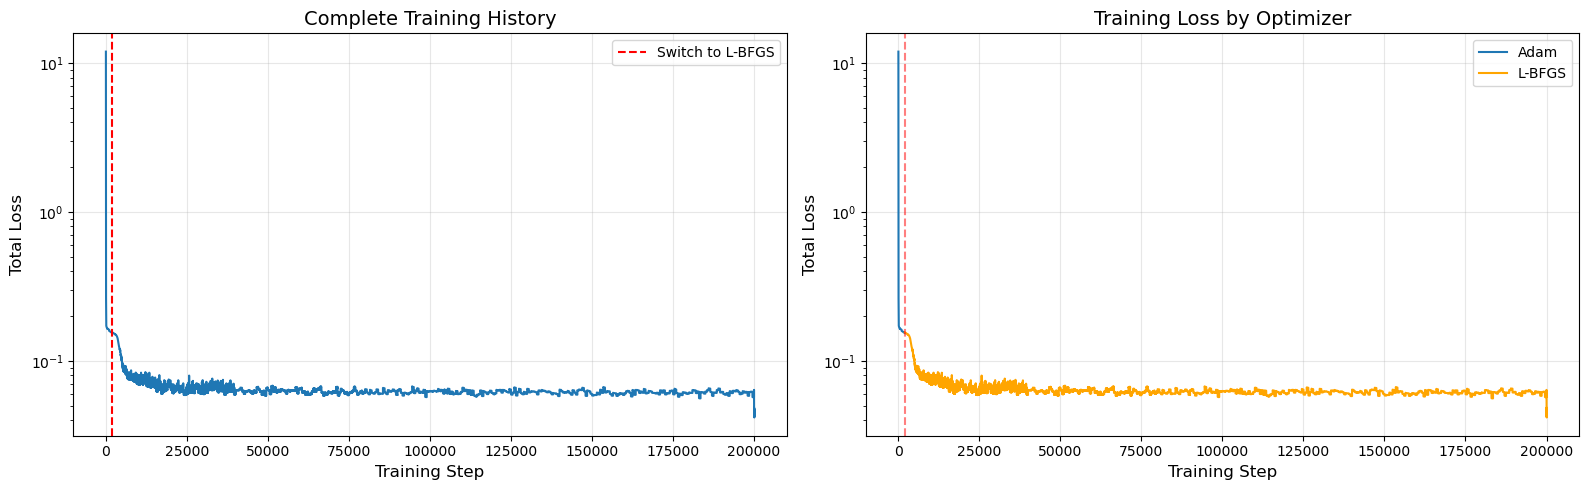

In [ ]:
# Load and plot training history
import numpy as np
import matplotlib.pyplot as plt

loss_history = np.load("loss_history.npy", allow_pickle=True).item()
adam_history = loss_history['adam']
lbfgs_history = loss_history['lbfgs']

# Combine for total view
n_adam = len(adam_history['total'])
n_lbfgs = len(lbfgs_history['total'])
total_steps = n_adam + n_lbfgs

# Concatenate for plotting
def concat_losses(key):
    return np.concatenate([adam_history[key], lbfgs_history[key]])

# Check if FEM error data is available
has_fem_error = len(adam_history.get('fem_mae', [])) > 0

if has_fem_error:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

# Top left: Total loss
total_loss = concat_losses('total')
axes[0].plot(total_loss, linewidth=1.5)
axes[0].axvline(x=n_adam, color='r', linestyle='--', label='Switch to L-BFGS')
axes[0].set_xlabel("Training Step", fontsize=12)
axes[0].set_ylabel("Total Loss", fontsize=12)
axes[0].set_title("Total Loss", fontsize=14)
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top middle: PDE loss
pde_loss = concat_losses('pde')
axes[1].plot(pde_loss, linewidth=1.5, color='green')
axes[1].axvline(x=n_adam, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel("Training Step", fontsize=12)
axes[1].set_ylabel("PDE Loss", fontsize=12)
axes[1].set_title("PDE Loss", fontsize=14)
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Top right or Bottom left: Boundary condition losses
ax_bc = axes[2] if has_fem_error else axes[2]
bc_sides_loss = concat_losses('bc_sides')
free_top_loss = concat_losses('free_top')
free_bot_loss = concat_losses('free_bot')
ax_bc.plot(bc_sides_loss, linewidth=1.5, label='BC Sides', color='blue')
ax_bc.plot(free_top_loss, linewidth=1.5, label='Free Top', color='cyan')
ax_bc.plot(free_bot_loss, linewidth=1.5, label='Free Bot', color='purple')
ax_bc.axvline(x=n_adam, color='r', linestyle='--', alpha=0.5)
ax_bc.set_xlabel("Training Step", fontsize=12)
ax_bc.set_ylabel("BC Loss", fontsize=12)
ax_bc.set_title("Boundary Condition Losses", fontsize=14)
ax_bc.set_yscale('log')
ax_bc.legend()
ax_bc.grid(True, alpha=0.3)

# Bottom left or Bottom right: Load loss
ax_load = axes[3] if has_fem_error else axes[3]
load_loss = concat_losses('load')
ax_load.plot(load_loss, linewidth=1.5, color='red')
ax_load.axvline(x=n_adam, color='r', linestyle='--', alpha=0.5)
ax_load.set_xlabel("Training Step", fontsize=12)
ax_load.set_ylabel("Load Loss", fontsize=12)
ax_load.set_title("Load BC Loss", fontsize=14)
ax_load.set_yscale('log')
ax_load.grid(True, alpha=0.3)

# FEM error plots (if available)
if has_fem_error:
    # Bottom middle: FEM MAE
    adam_fem_epochs = adam_history['epochs']
    adam_fem_mae = adam_history['fem_mae']
    lbfgs_fem_steps = [n_adam + s for s in lbfgs_history['steps']]
    lbfgs_fem_mae = lbfgs_history['fem_mae']
    
    axes[4].plot(adam_fem_epochs, adam_fem_mae, 'o-', linewidth=1.5, label='Adam', color='blue')
    axes[4].plot(lbfgs_fem_steps, lbfgs_fem_mae, 's-', linewidth=1.5, label='L-BFGS', color='orange')
    axes[4].axvline(x=n_adam, color='r', linestyle='--', alpha=0.5)
    axes[4].set_xlabel("Training Step", fontsize=12)
    axes[4].set_ylabel("FEM MAE", fontsize=12)
    axes[4].set_title("FEM Mean Absolute Error", fontsize=14)
    axes[4].set_yscale('log')
    axes[4].legend()
    axes[4].grid(True, alpha=0.3)
    
    # Bottom right: FEM Max Error
    adam_fem_max = adam_history['fem_max_err']
    lbfgs_fem_max = lbfgs_history['fem_max_err']
    
    axes[5].plot(adam_fem_epochs, adam_fem_max, 'o-', linewidth=1.5, label='Adam', color='blue')
    axes[5].plot(lbfgs_fem_steps, lbfgs_fem_max, 's-', linewidth=1.5, label='L-BFGS', color='orange')
    axes[5].axvline(x=n_adam, color='r', linestyle='--', alpha=0.5)
    axes[5].set_xlabel("Training Step", fontsize=12)
    axes[5].set_ylabel("FEM Max Error", fontsize=12)
    axes[5].set_title("FEM Maximum Error", fontsize=14)
    axes[5].set_yscale('log')
    axes[5].legend()
    axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)

print(f"Training completed in {total_steps} steps")
print(f"  Adam phase: {n_adam} epochs")
print(f"  L-BFGS phase: {n_lbfgs} steps")
print(f"\nFinal losses (after L-BFGS):")
print(f"  Total: {lbfgs_history['total'][-1]:.6e}")
print(f"  PDE: {lbfgs_history['pde'][-1]:.6e}")
print(f"  BC Sides: {lbfgs_history['bc_sides'][-1]:.6e}")
print(f"  Free Top: {lbfgs_history['free_top'][-1]:.6e}")
print(f"  Free Bot: {lbfgs_history['free_bot'][-1]:.6e} ← Check this!")
print(f"  Load: {lbfgs_history['load'][-1]:.6e}")
if has_fem_error:
    print(f"  FEM MAE: {lbfgs_history['fem_mae'][-1]:.6e}")
    print(f"  FEM Max Error: {lbfgs_history['fem_max_err'][-1]:.6e}")
print(f"\nAfter Adam phase:")
print(f"  Total: {adam_history['total'][-1]:.6e}")
print(f"  Free Bot: {adam_history['free_bot'][-1]:.6e}")
if has_fem_error and len(adam_history['fem_mae']) > 0:
    print(f"  FEM MAE: {adam_history['fem_mae'][-1]:.6e}")
print(f"\nInitial total loss: {adam_history['total'][0]:.6e}")
print(f"Final reduction: {adam_history['total'][0] / lbfgs_history['total'][-1]:.2f}x")
print("\nSaved training_history.png")
plt.show()

# Compare PINN and FEM Solutions

Load and compare the results from both methods.

In [ ]:
# Now compare PINN and FEM
import numpy as np
import matplotlib.pyplot as plt
import torch
import pinn_config as config
import model

print("Loading FEA Solution...")
data = np.load("fea_solution.npy", allow_pickle=True).item()
X_fea = data['x']
Y_fea = data['y']
Z_fea = data['z']
U_fea = data['u']

print(f"FEA Grid: {X_fea.shape}")

# Load PINN model
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

pinn = model.MultiLayerPINN().to(device)
pinn.load_state_dict(torch.load("pinn_model.pth", map_location=device, weights_only=True))
pinn.eval()
print("PINN model loaded")

# Evaluate PINN on FEM grid
pts = np.stack([X_fea.ravel(), Y_fea.ravel(), Z_fea.ravel()], axis=1)
U_pinn_flat = np.zeros_like(pts)

with torch.no_grad():
    pts_tensor = torch.tensor(pts, dtype=torch.float32).to(device)
    U_pinn_flat = pinn(pts_tensor, 0).cpu().numpy()

U_pinn = U_pinn_flat.reshape(U_fea.shape)
print("PINN predictions computed")

Loading FEA Solution...
FEA Grid: (31, 31, 11)
PINN model loaded
PINN predictions computed


In [ ]:
# Compute comparison metrics on top surface
u_z_fea_top = U_fea[:, :, -1, 2]
u_z_pinn_top = U_pinn[:, :, -1, 2]

abs_diff = np.abs(u_z_fea_top - u_z_pinn_top)
mae = np.mean(abs_diff)
max_err = np.max(abs_diff)
denom = np.max(np.abs(u_z_fea_top))
mae_pct = (mae / denom) * 100.0 if denom > 0 else 0.0

print(f"\n{'='*50}")
print(f"Comparison Results (Top Surface u_z):")
print(f"{'='*50}")
print(f"MAE: {mae:.6f}")
print(f"MAE % of max |FEA u_z|: {mae_pct:.2f}%")
print(f"Max Error: {max_err:.6f}")
print(f"Peak Deflection FEA: {u_z_fea_top.min():.6f}")
print(f"Peak Deflection PINN: {u_z_pinn_top.min():.6f}")
print(f"{'='*50}")


Comparison Results (Top Surface u_z):
MAE: 0.075642
MAE % of max |FEA u_z|: 13.05%
Max Error: 0.189249
Peak Deflection FEA: -0.579471
Peak Deflection PINN: -0.391477


Saved comparison_top.png


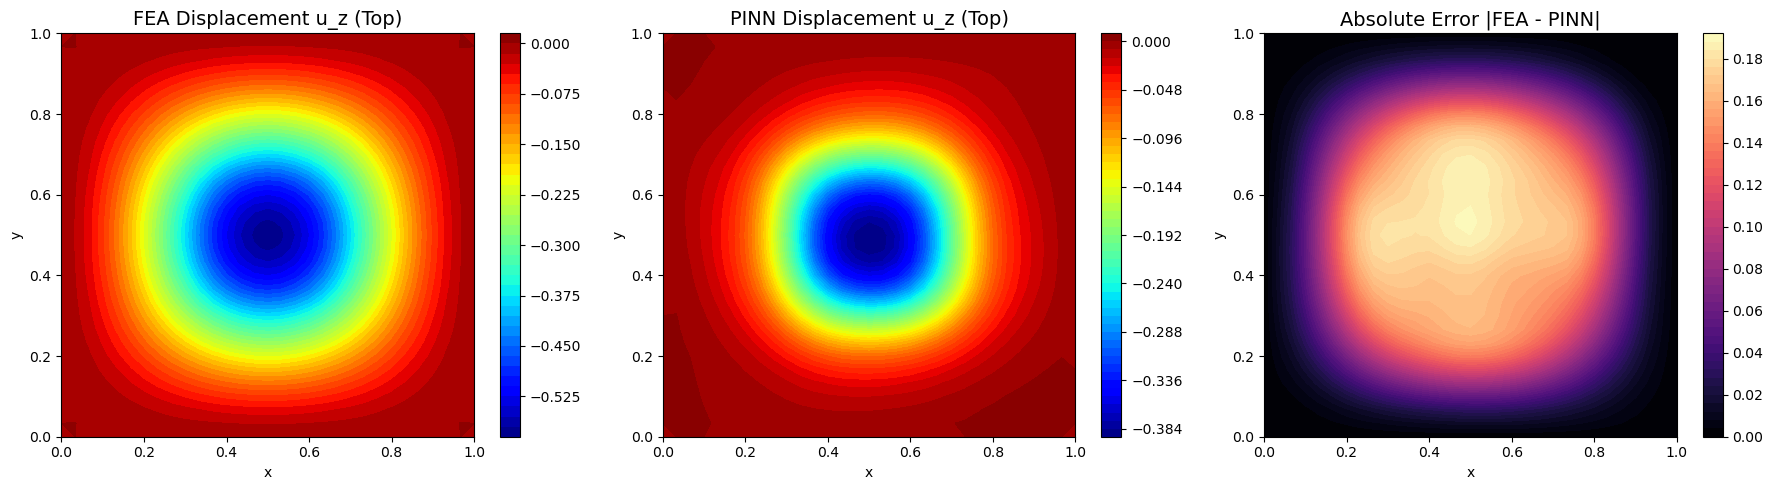

In [ ]:
# Visualize comparison - Top surface
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# FEA
c1 = axes[0].contourf(X_fea[:,:,0], Y_fea[:,:,0], u_z_fea_top, levels=50, cmap='jet')
axes[0].set_title("FEA Displacement u_z (Top)", fontsize=14)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(c1, ax=axes[0])

# PINN
c2 = axes[1].contourf(X_fea[:,:,0], Y_fea[:,:,0], u_z_pinn_top, levels=50, cmap='jet')
axes[1].set_title("PINN Displacement u_z (Top)", fontsize=14)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(c2, ax=axes[1])

# Error
c3 = axes[2].contourf(X_fea[:,:,0], Y_fea[:,:,0], abs_diff, levels=50, cmap='magma')
axes[2].set_title("Absolute Error |FEA - PINN|", fontsize=14)
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.savefig("comparison_top.png", dpi=150)
print("Saved comparison_top.png")
plt.show()

Saved comparison_cross_section.png


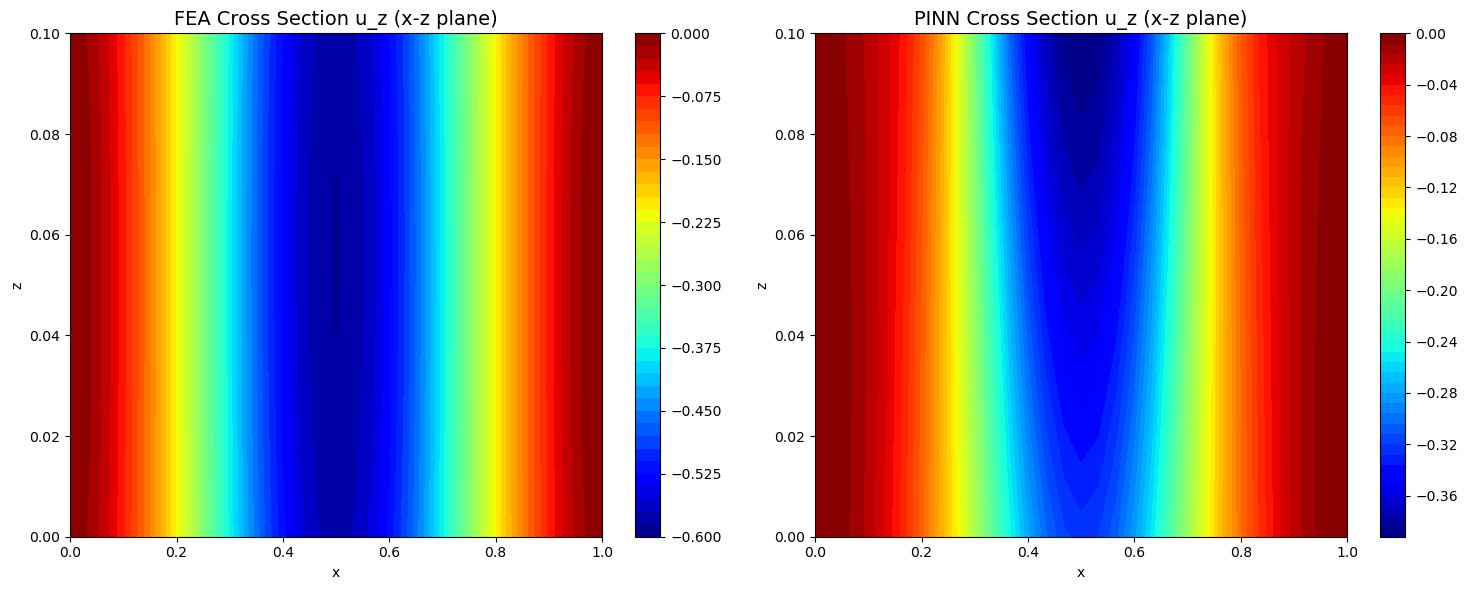

In [ ]:
# Visualize cross-section (x-z plane at mid-y)
mid_y = U_fea.shape[1] // 2

xz_X = X_fea[:, mid_y, :]
xz_Z = Z_fea[:, mid_y, :]
xz_Uz_fea = U_fea[:, mid_y, :, 2]
xz_Uz_pinn = U_pinn[:, mid_y, :, 2]

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))

c4 = axes2[0].contourf(xz_X, xz_Z, xz_Uz_fea, levels=50, cmap='jet')
axes2[0].set_title("FEA Cross Section u_z (x-z plane)", fontsize=14)
axes2[0].set_xlabel("x")
axes2[0].set_ylabel("z")
plt.colorbar(c4, ax=axes2[0])

c5 = axes2[1].contourf(xz_X, xz_Z, xz_Uz_pinn, levels=50, cmap='jet')
axes2[1].set_title("PINN Cross Section u_z (x-z plane)", fontsize=14)
axes2[1].set_xlabel("x")
axes2[1].set_ylabel("z")
plt.colorbar(c5, ax=axes2[1])

plt.tight_layout()
plt.savefig("comparison_cross_section.png", dpi=150)
print("Saved comparison_cross_section.png")
plt.show()

# Visualize PDE Residuals

Check how well the PINN satisfies the equilibrium equations.

In [ ]:
# Compute PDE residual on x-z plane at mid-y
import physics

# Sample points on x-z plane
nx_res, nz_res = 50, 20
x_res = np.linspace(0, 1.0, nx_res)
z_res = np.linspace(0, 0.1, nz_res)
y_mid = 0.5

X_res, Z_res = np.meshgrid(x_res, z_res, indexing='ij')
Y_res = np.ones_like(X_res) * y_mid

pts_res = np.stack([X_res.ravel(), Y_res.ravel(), Z_res.ravel()], axis=1)
pts_res_tensor = torch.tensor(pts_res, dtype=torch.float32, requires_grad=True).to(device)

# Get Lame parameters
lm, mu = config.Lame_Params[0]

# Compute displacement
u = pinn(pts_res_tensor, 0)

# Compute gradients and stress
grad_u = physics.gradient(u, pts_res_tensor)
eps = physics.strain(grad_u)
sig = physics.stress(eps, lm, mu)

# Compute divergence (PDE residual)
div_sigma = physics.divergence(sig, pts_res_tensor)
residual = -div_sigma  # Equilibrium: -div(sigma) = 0

# Convert to numpy and compute magnitude
residual_np = residual.detach().cpu().numpy()
residual_mag = np.sqrt(np.sum(residual_np**2, axis=1))
residual_mag_grid = residual_mag.reshape(X_res.shape)

print(f"PDE Residual Statistics (x-z plane):")
print(f"  Mean: {residual_mag.mean():.6e}")
print(f"  Max: {residual_mag.max():.6e}")
print(f"  Min: {residual_mag.min():.6e}")

PDE Residual Statistics (x-z plane):
  Mean: 8.737765e-02
  Max: 5.323768e-01
  Min: 4.528855e-03


Saved pde_residual_xz.png


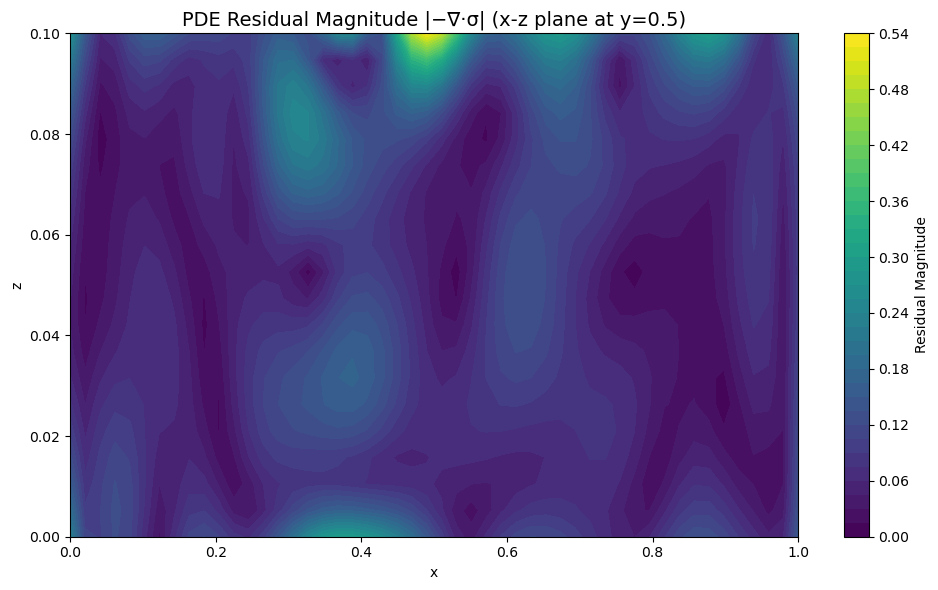

In [ ]:
# Plot PDE residual magnitude
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

c = ax.contourf(X_res, Z_res, residual_mag_grid, levels=50, cmap='viridis')
ax.set_title("PDE Residual Magnitude |−∇·σ| (x-z plane at y=0.5)", fontsize=14)
ax.set_xlabel("x")
ax.set_ylabel("z")
cbar = plt.colorbar(c, ax=ax)
cbar.set_label("Residual Magnitude")

plt.tight_layout()
plt.savefig("pde_residual_xz.png", dpi=150)
print("Saved pde_residual_xz.png")
plt.show()

Saved pde_residual_components_xz.png


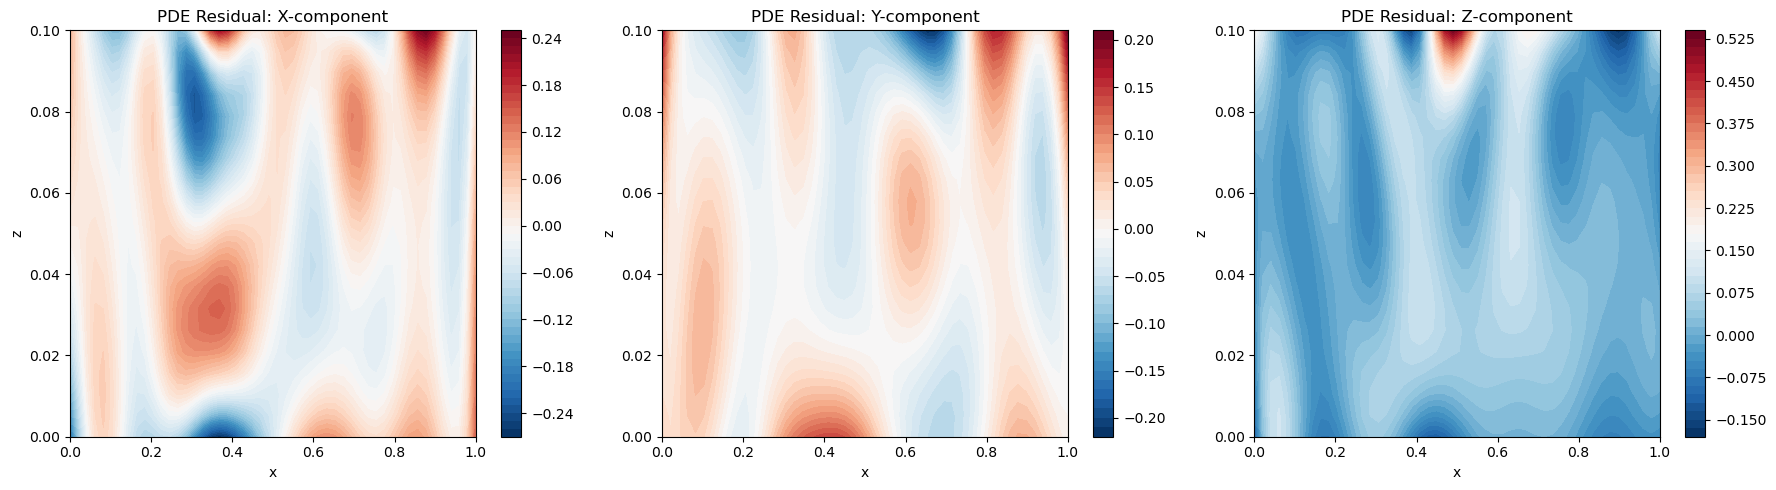

In [ ]:
# Plot individual components of PDE residual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residual_x = residual_np[:, 0].reshape(X_res.shape)
residual_y = residual_np[:, 1].reshape(X_res.shape)
residual_z = residual_np[:, 2].reshape(X_res.shape)

# X-component
c1 = axes[0].contourf(X_res, Z_res, residual_x, levels=50, cmap='RdBu_r')
axes[0].set_title("PDE Residual: X-component", fontsize=12)
axes[0].set_xlabel("x")
axes[0].set_ylabel("z")
plt.colorbar(c1, ax=axes[0])

# Y-component
c2 = axes[1].contourf(X_res, Z_res, residual_y, levels=50, cmap='RdBu_r')
axes[1].set_title("PDE Residual: Y-component", fontsize=12)
axes[1].set_xlabel("x")
axes[1].set_ylabel("z")
plt.colorbar(c2, ax=axes[1])

# Z-component
c3 = axes[2].contourf(X_res, Z_res, residual_z, levels=50, cmap='RdBu_r')
axes[2].set_title("PDE Residual: Z-component", fontsize=12)
axes[2].set_xlabel("x")
axes[2].set_ylabel("z")
plt.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.savefig("pde_residual_components_xz.png", dpi=150)
print("Saved pde_residual_components_xz.png")
plt.show()

# Visualize Traction (σ·n) on Top and Bottom Surfaces

Check boundary condition enforcement on free surfaces.

In [ ]:
# Compute traction on top surface (z=H)
nx_surf, ny_surf = 50, 50
x_surf = np.linspace(0, 1.0, nx_surf)
y_surf = np.linspace(0, 1.0, ny_surf)

X_top, Y_top = np.meshgrid(x_surf, y_surf, indexing='ij')
Z_top = np.ones_like(X_top) * 0.1  # z = H

pts_top = np.stack([X_top.ravel(), Y_top.ravel(), Z_top.ravel()], axis=1)
pts_top_tensor = torch.tensor(pts_top, dtype=torch.float32, requires_grad=True).to(device)

# Compute displacement and stress on top
u_top = pinn(pts_top_tensor, 0)
grad_u_top = physics.gradient(u_top, pts_top_tensor)
eps_top = physics.strain(grad_u_top)
sig_top = physics.stress(eps_top, lm, mu)

# Traction: T = sigma · n, where n = [0, 0, 1] for top
# T = [sigma_xz, sigma_yz, sigma_zz]
T_top = sig_top[:, :, 2].detach().cpu().numpy()
T_top_x = T_top[:, 0].reshape(X_top.shape)
T_top_y = T_top[:, 1].reshape(X_top.shape)
T_top_z = T_top[:, 2].reshape(X_top.shape)

print(f"\nTop Surface Traction Statistics:")
print(f"  T_x - Mean: {T_top[:, 0].mean():.6e}, Max: {np.abs(T_top[:, 0]).max():.6e}")
print(f"  T_y - Mean: {T_top[:, 1].mean():.6e}, Max: {np.abs(T_top[:, 1]).max():.6e}")
print(f"  T_z - Mean: {T_top[:, 2].mean():.6e}, Max: {np.abs(T_top[:, 2]).max():.6e}")
print(f"  (Expected: T_x=0, T_y=0, T_z=-1.0 on load patch, T_z=0 elsewhere)")


Top Surface Traction Statistics:
  T_x - Mean: -4.135986e-04, Max: 1.892892e-01
  T_y - Mean: -3.415727e-03, Max: 1.770772e-01
  T_z - Mean: -1.042448e-01, Max: 1.019421e+00
  (Expected: T_x=0, T_y=0, T_z=-1.0 on load patch, T_z=0 elsewhere)


In [ ]:
# Compute traction on bottom surface (z=0)
Z_bot = np.zeros_like(X_top)  # z = 0

pts_bot = np.stack([X_top.ravel(), Y_top.ravel(), Z_bot.ravel()], axis=1)
pts_bot_tensor = torch.tensor(pts_bot, dtype=torch.float32, requires_grad=True).to(device)

# Compute displacement and stress on bottom
u_bot = pinn(pts_bot_tensor, 0)
grad_u_bot = physics.gradient(u_bot, pts_bot_tensor)
eps_bot = physics.strain(grad_u_bot)
sig_bot = physics.stress(eps_bot, lm, mu)

# Traction: T = sigma · n, where n = [0, 0, -1] for bottom
# T = -[sigma_xz, sigma_yz, sigma_zz]
T_bot = -sig_bot[:, :, 2].detach().cpu().numpy()
T_bot_x = T_bot[:, 0].reshape(X_top.shape)
T_bot_y = T_bot[:, 1].reshape(X_top.shape)
T_bot_z = T_bot[:, 2].reshape(X_top.shape)

print(f"\nBottom Surface Traction Statistics:")
print(f"  T_x - Mean: {T_bot[:, 0].mean():.6e}, Max: {np.abs(T_bot[:, 0]).max():.6e}")
print(f"  T_y - Mean: {T_bot[:, 1].mean():.6e}, Max: {np.abs(T_bot[:, 1]).max():.6e}")
print(f"  T_z - Mean: {T_bot[:, 2].mean():.6e}, Max: {np.abs(T_bot[:, 2]).max():.6e}")
print(f"  (Expected: T_x=0, T_y=0, T_z=0)")


Bottom Surface Traction Statistics:
  T_x - Mean: -9.887696e-04, Max: 2.126226e-01
  T_y - Mean: 9.282056e-04, Max: 2.100824e-01
  T_z - Mean: 1.092238e-01, Max: 7.801922e-01
  (Expected: T_x=0, T_y=0, T_z=0)


# Debug: Check Bottom BC Loss

Verify that the bottom free surface BC is being satisfied by the trained model.

In [ ]:
# Sample bottom surface points and compute BC loss as in training
import data as data_module

test_data = data_module.get_data()
x_bot_test = test_data['bottom'].to(device)
x_bot_test.requires_grad = True

u_bot_test = pinn(x_bot_test, 0)
grad_u_bot_test = physics.gradient(u_bot_test, x_bot_test)
eps_bot_test = physics.strain(grad_u_bot_test)
sig_bot_test = physics.stress(eps_bot_test, lm, mu)

# Bottom surface: n = (0, 0, -1)
# T = sigma · n = -sigma[:,:,2]
T_bot_test = -sig_bot_test[:, :, 2]

# Compute loss
loss_bot_test = torch.mean(T_bot_test**2)

print(f"\n{'='*50}")
print(f"Bottom Surface BC Violation Check:")
print(f"{'='*50}")
print(f"Bottom BC Loss (mean T²): {loss_bot_test.item():.6e}")
print(f"Mean |T|: {torch.mean(torch.abs(T_bot_test)).item():.6e}")
print(f"Max |T|: {torch.max(torch.abs(T_bot_test)).item():.6e}")
print(f"\nComponent-wise (should all be ≈0):")
print(f"  T_x: mean={T_bot_test[:, 0].mean().item():.6e}, max_abs={torch.abs(T_bot_test[:, 0]).max().item():.6e}")
print(f"  T_y: mean={T_bot_test[:, 1].mean().item():.6e}, max_abs={torch.abs(T_bot_test[:, 1]).max().item():.6e}")
print(f"  T_z: mean={T_bot_test[:, 2].mean().item():.6e}, max_abs={torch.abs(T_bot_test[:, 2]).max().item():.6e}")
print(f"{'='*50}")

# Check if there's actually pressure on bottom (should NOT be)
print(f"\nDirect σ_zz at bottom (should be ≈0 for free surface):")
print(f"  Mean σ_zz: {sig_bot_test[:, 2, 2].mean().item():.6e}")
print(f"  Max |σ_zz|: {torch.abs(sig_bot_test[:, 2, 2]).max().item():.6e}")


Bottom Surface BC Violation Check:
Bottom BC Loss (mean T²): 1.943040e-02
Mean |T|: 6.465086e-02
Max |T|: 7.675889e-01

Component-wise (should all be ≈0):
  T_x: mean=-6.260829e-04, max_abs=2.129550e-01
  T_y: mean=1.748140e-03, max_abs=2.092219e-01
  T_z: mean=1.051294e-01, max_abs=7.675889e-01

Direct σ_zz at bottom (should be ≈0 for free surface):
  Mean σ_zz: -1.051294e-01
  Max |σ_zz|: 7.675889e-01


**Analysis:**

If the bottom BC loss is high (e.g., > 1e-3) and σ_zz ≈ -1 at the bottom center, this indicates the **bottom free surface BC is not being properly enforced** during training.

Possible causes:
1. **Loss weight imbalance**: The load BC weight (5000.0) might be dominating, preventing proper bottom BC satisfaction
2. **Insufficient sampling**: Not enough collocation points on the bottom surface
3. **Training not converged**: Model hasn't learned to satisfy all BCs simultaneously
4. **Coordinate scaling**: The z-direction issue might be affecting gradient computation

The PINN may be incorrectly "mirroring" the top pressure load to the bottom, treating it symmetrically rather than enforcing the free BC.

Saved traction_top_surface.png


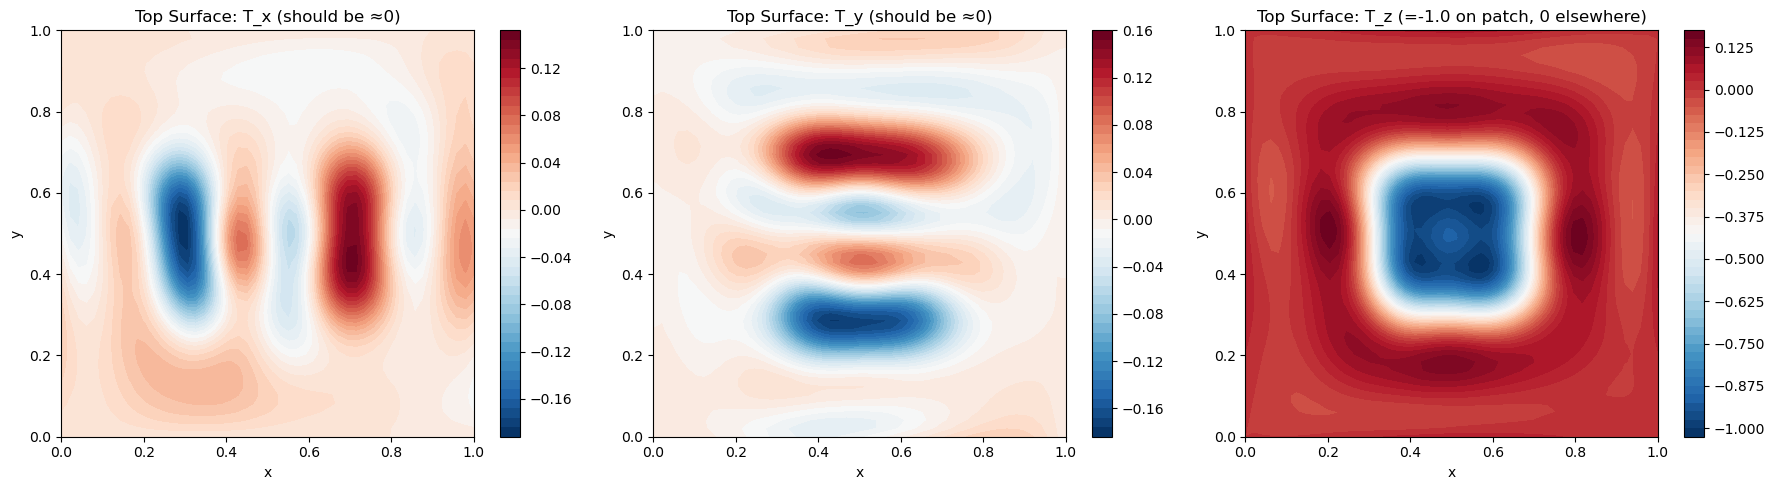

In [ ]:
# Plot top surface traction components
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# T_x on top
c1 = axes[0].contourf(X_top, Y_top, T_top_x, levels=50, cmap='RdBu_r')
axes[0].set_title("Top Surface: T_x (should be ≈0)", fontsize=12)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(c1, ax=axes[0])

# T_y on top
c2 = axes[1].contourf(X_top, Y_top, T_top_y, levels=50, cmap='RdBu_r')
axes[1].set_title("Top Surface: T_y (should be ≈0)", fontsize=12)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(c2, ax=axes[1])

# T_z on top
c3 = axes[2].contourf(X_top, Y_top, T_top_z, levels=50, cmap='RdBu_r')
axes[2].set_title("Top Surface: T_z (=-1.0 on patch, 0 elsewhere)", fontsize=12)
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.savefig("traction_top_surface.png", dpi=150)
print("Saved traction_top_surface.png")
plt.show()

Saved traction_bottom_surface.png


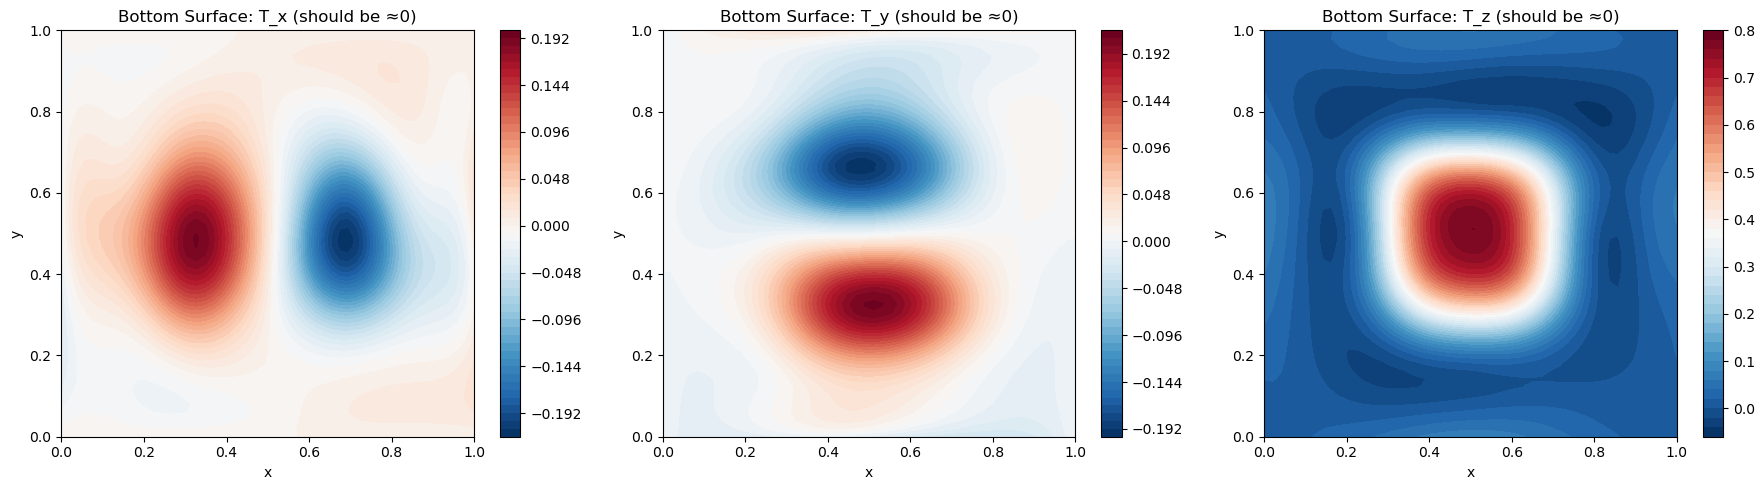

In [ ]:
# Plot bottom surface traction components
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# T_x on bottom
c1 = axes[0].contourf(X_top, Y_top, T_bot_x, levels=50, cmap='RdBu_r')
axes[0].set_title("Bottom Surface: T_x (should be ≈0)", fontsize=12)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(c1, ax=axes[0])

# T_y on bottom
c2 = axes[1].contourf(X_top, Y_top, T_bot_y, levels=50, cmap='RdBu_r')
axes[1].set_title("Bottom Surface: T_y (should be ≈0)", fontsize=12)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(c2, ax=axes[1])

# T_z on bottom
c3 = axes[2].contourf(X_top, Y_top, T_bot_z, levels=50, cmap='RdBu_r')
axes[2].set_title("Bottom Surface: T_z (should be ≈0)", fontsize=12)
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.savefig("traction_bottom_surface.png", dpi=150)
print("Saved traction_bottom_surface.png")
plt.show()